In [161]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Libraries imported successfully.")

Libraries imported successfully.


In [162]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    r"C:\Users\Matrix Computer\Documents\pfe\FoodDataSet\train",
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    r"C:\Users\Matrix Computer\Documents\pfe\FoodDataSet\validation",
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    r"C:\Users\Matrix Computer\Documents\pfe\FoodDataSet\test",
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

print("\nClass mapping:", train_generator.class_indices)

Found 2409 images belonging to 3 classes.
Found 833 images belonging to 3 classes.
Found 851 images belonging to 3 classes.

Class mapping: {'Bread': 0, 'Dairy product': 1, 'Egg': 2}


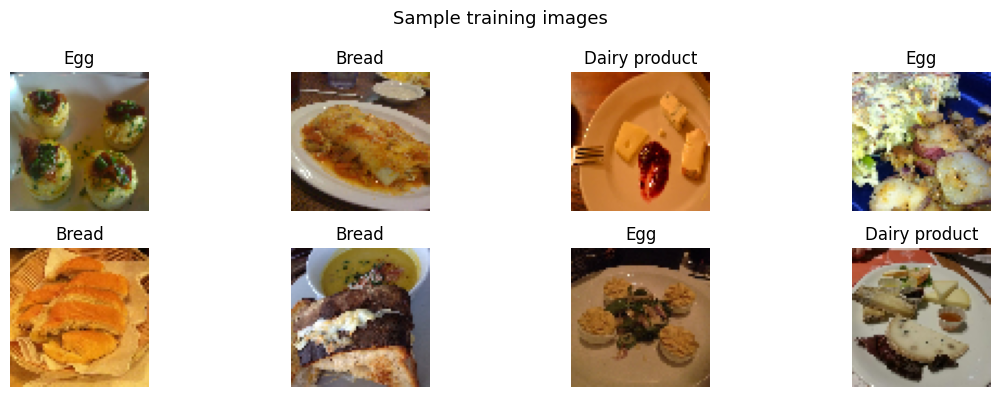

In [163]:
images, labels = next(train_generator)
class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')
plt.suptitle('Sample training images', fontsize=13)
plt.tight_layout()
plt.show()

In [164]:
num_classes = train_generator.num_classes

model = Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(128, activation="relu"),   # try: 256, 64, 32
    Dense(64,  activation="relu"),   # try: removing this layer, or adding one more
    
    Dense(num_classes, activation="softmax")
])

model.summary()

c:\Users\Matrix Computer\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_17 (Flatten)            │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,443 (6.03 MB)

 Trainable params: 1,581,443 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

In [165]:
import tensorflow as tf
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),                   
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled.")

Model compiled.


In [166]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10              # try: 20, 30
)

Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.4081 - loss: 9.7003 - val_accuracy: 0.5030 - val_loss: 0.9691
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.4815 - loss: 1.0495 - val_accuracy: 0.4754 - val_loss: 1.0204
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.4961 - loss: 1.0546 - val_accuracy: 0.4826 - val_loss: 1.0419
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.5189 - loss: 0.9802 - val_accuracy: 0.4166 - val_loss: 1.2352
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.5093 - loss: 0.9715 - val_accuracy: 0.4970 - val_loss: 0.9961
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.5442 - loss: 0.9232 - val_accuracy: 0.5366 - val_loss: 1.0072
Epoch 7/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.5376 - loss: 0.9620 - val_accuracy: 0.5162 - val_loss: 0.9696
Epoch 8/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.5405 - loss: 0.9314 - val_accuracy: 0.4322 - v

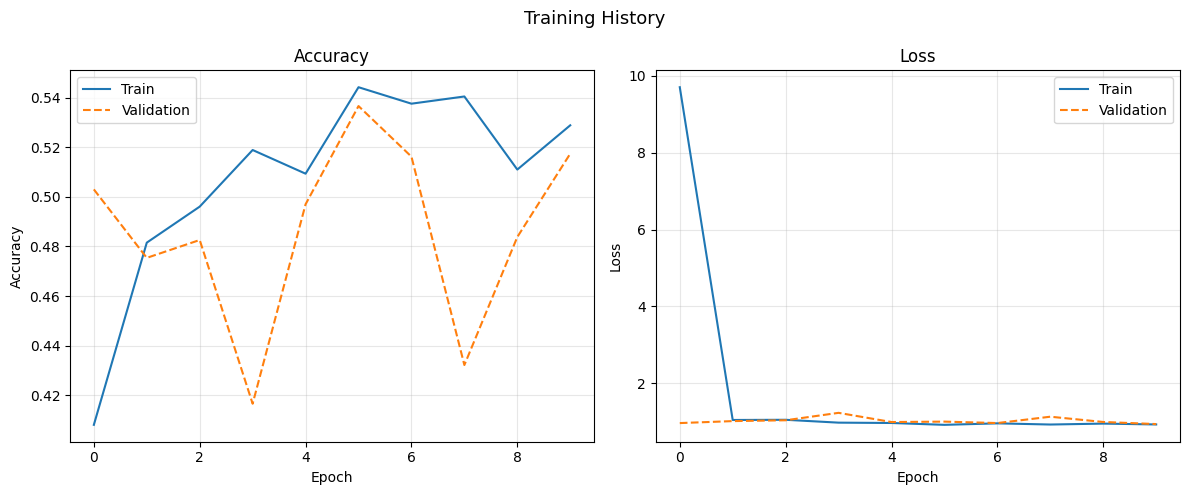

In [167]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"],     label="Train")
plt.plot(history.history["val_accuracy"], label="Validation", linestyle="--")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"],     label="Train")
plt.plot(history.history["val_loss"], label="Validation", linestyle="--")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle("Training History", fontsize=13)
plt.tight_layout()
plt.show()

In [168]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.5006 - loss: 1.0067
Test Loss:     1.0067
Test Accuracy: 0.5006 (50.1%)


27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step


<Figure size 600x500 with 0 Axes>

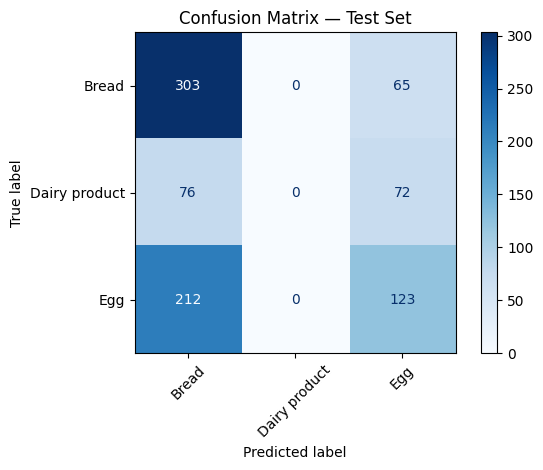

In [169]:
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

In [171]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=labels))

               precision    recall  f1-score   support

        Bread       0.51      0.82      0.63       368
Dairy product       0.00      0.00      0.00       148
          Egg       0.47      0.37      0.41       335

     accuracy                           0.50       851
    macro avg       0.33      0.40      0.35       851
 weighted avg       0.41      0.50      0.44       851



c:\Users\Matrix Computer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Matrix Computer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Matrix Computer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

---
## Hyperparameter Experiments

Go back to Steps 4, 5 and 6 and try the following changes one at a time. Each time, re-run all cells from Step 4 onwards and note the results in the table below.

| Experiment | Change | Train Acc | Val Acc | Test Acc | Observation |
|------------|--------|-----------|---------|----------|-------------|
| Baseline   | Default (128→64, adam, 10 epochs) |57% |55% |52.6% |acceptable performance Noticeable gap between training and validation accuracy → slight overfitting |
| Exp 1      | Neurons: 256→128 |56%|53.1% |51.6% |Accuracy decreased slightly → fewer neurons reduce learning capacity|
| Exp 2      | Remove one hidden layer |59.2% |53.8% |54.9% |Test accuracy improved→ simpler model can generalize better |
| Exp 3      | Add a third hidden layer Dense(32) |57.9%|54.6%|51.0% |Train went slightly down, Test decreased → extra layer didn’t help|
| Exp 4      | Activation: relu → tanh |41.5%|39.3%|39.4%|Very poor performance → tanh not suitable here. |
| Exp 5      | Epochs: 10 → 20 | 64.3%| 50.5%|50.8% |creating a large gap that clearly indicates overfitting |
| Exp 6      | Learning rate: 0.001 → 0.01 |52.9% |51.7%|50.1%|High learning rate → model jumps over optimum → unstable training → low accuracy|

**Questions:**
1. Which configuration gives the best test accuracy?
Exp 2 (Remove one hidden layer) → Test Acc = 54.9%
2. In which experiment do you observe overfitting? How can you see it on the curves?
Exp 5 (Epochs 10 → 20)
Overfitting clues:
Train Accuracy high (64.3%)
Validation Accuracy much lower (50.5%)
On the curve: Train curve rises above Val curve → big gap = overfitting
3. What is the effect of increasing the number of neurons?
More neurons don’t always improve performance.
In Exp 1, fewer neurons slightly reduced accuracy → network has less capacity.
Too many neurons can overfit or complicate learning
4. Why does a very high learning rate sometimes give poor results?
Train accuracy unstable becauce large steps during optimization → might overshoot minima → model doesn’t converge well

---
*TP 1 — Artificial Neural Networks*